# BioListen VN — RFCx Preprocessing Pipeline (`species_head`) [On-Demand Extraction]

Notebook này thực hiện tiền xử lý cho bộ dữ liệu **RFCx (Rainforest Connection)** phục vụ nhánh nhận loại loài tự nhiên (`species_head`).

### Chiến lược tối ưu dung lượng ổ cứng (On-Demand Extraction):
Để tránh việc đầy dung lượng ổ đĩa cục bộ Colab do bộ dữ liệu RFCx raw rất lớn (~5.5 GB), notebook này sử dụng phương pháp **giải nén theo yêu cầu (On-Demand Extraction)**:
- Lập chỉ mục các tệp tin âm thanh `.flac` nằm trong file zip từ Google Drive vào bộ nhớ RAM.
- Đọc trực tiếp các tệp metadata `train_tp.csv` và `train_fp.csv` từ file zip.
- Đối với mỗi mẫu cần tiền xử lý, giải nén **duy nhất** file FLAC tương ứng ra bộ nhớ cục bộ tạm, load dữ liệu, cắt khoảng thời gian 5s xung quanh tiếng kêu, resample, trích xuất spectrogram, lưu thành tensor `.pt` cục bộ và **xóa ngay lập tức** file FLAC raw trước khi sang mẫu kế tiếp.
- Sau cùng, nén các file `.pt` TP và FP vào các file zip tương ứng lưu trực tiếp trên Google Drive.

### Quy trình tiền xử lý:
1. Chuẩn hóa về **Mono**, resample về **32,000 Hz**.
2. Cắt cửa sổ **5.0 giây** xoay quanh tâm tiếng kêu `t_center = (t_min + t_max) / 2`.
3. Trích xuất **Log-Mel Spectrogram** ($f_{min} = 200$ Hz để lọc tiếng ù nền ở thực địa, $f_{max} = 15,000$ Hz, $n_{mels} = 128$).
4. Resize song tuyến (bilinear) và nhân bản thành 3 kênh màu RGB `(3, 224, 224)`.
5. Lưu trữ các tensor dưới dạng tệp PyTorch `.pt` và xuất tệp metadata CSV tương ứng.

## 1. Kết nối Google Drive & Thiết lập Đường dẫn

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
import shutil
from tqdm import tqdm

# Cấu hình đường dẫn đầu vào và đầu ra trên Google Drive
drive_raw_zip = '/content/drive/MyDrive/Datasets/BioListenVN/raw_zips/rfcx-species-audio-detection.zip'
drive_processed_dir = '/content/drive/MyDrive/Datasets/BioListenVN/processed'

# Đường dẫn làm việc trên cục bộ
local_processed_dir_tp = '/content/rfcx_processed_tp'
local_processed_dir_fp = '/content/rfcx_processed_fp'

os.makedirs(drive_processed_dir, exist_ok=True)
os.makedirs(local_processed_dir_tp, exist_ok=True)
os.makedirs(local_processed_dir_fp, exist_ok=True)

if os.path.exists(drive_raw_zip):
    print(f"Tìm thấy raw zip file tại: {drive_raw_zip}")
else:
    print(f"LỖI: Không tìm thấy file tại {drive_raw_zip}. Vui lòng upload dữ liệu lên Drive.")

Mounted at /content/drive
Tìm thấy raw zip file tại: /content/drive/MyDrive/Datasets/BioListenVN/raw_zips/rfcx-species-audio-detection.zip


## 2. Import các Thư viện cần thiết

In [2]:
import torch
import torchaudio
import torchaudio.transforms as T
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
import glob

print("PyTorch version:", torch.__version__)
print("Torchaudio version:", torchaudio.__version__)

PyTorch version: 2.11.0+cpu
Torchaudio version: 2.11.0+cpu


## 3. Lập chỉ mục Zip file và Đọc Metadata trực tiếp vào bộ nhớ RAM

In [3]:
if os.path.exists(drive_raw_zip):
    with zipfile.ZipFile(drive_raw_zip, 'r') as z:
        print("Đang lập chỉ mục các file trong zip...")
        all_files = z.namelist()
        flac_in_zip = [p for p in all_files if p.endswith('.flac')]
        file_to_zip_path = {os.path.basename(p): p for p in flac_in_zip}
        print(f"Tìm thấy {len(flac_in_zip)} file flac trong zip.")

        # Đọc train_tp.csv trực tiếp
        tp_csv_member = [f for f in all_files if f.endswith('train_tp.csv')]
        if tp_csv_member:
            with z.open(tp_csv_member[0]) as f:
                df_tp = pd.read_csv(f)
            print(f"Đã đọc train_tp.csv trực tiếp (Số dòng: {len(df_tp)})")
        else:
            print("Cảnh báo: Không tìm thấy train_tp.csv trong zip.")

        # Đọc train_fp.csv trực tiếp
        fp_csv_member = [f for f in all_files if f.endswith('train_fp.csv')]
        if fp_csv_member:
            with z.open(fp_csv_member[0]) as f:
                df_fp = pd.read_csv(f)
            print(f"Đã đọc train_fp.csv trực tiếp (Số dòng: {len(df_fp)})")

Đang lập chỉ mục các file trong zip...
Tìm thấy 6719 file flac trong zip.
Đã đọc train_tp.csv trực tiếp (Số dòng: 1216)
Đã đọc train_fp.csv trực tiếp (Số dòng: 7781)


## 4. Cấu hình Tham số và Xây dựng Lớp Preprocessor cho Loài

In [4]:
# Cấu hình thống nhất theo tài liệu EDA_pipeline.md
AUDIO_CONFIG = {
    "sample_rate": 32000,
    "duration_sec": 5,
    "n_samples": 32000 * 5,
    "n_fft": 2048,
    "hop_length": 512,
    "n_mels": 128,
    "fmin_species": 200,        # Lọc gió ù nền ở thực địa (200Hz)
    "fmax": 15000,
}

class RFCxAudioPreprocessor:
    def __init__(self, config=AUDIO_CONFIG):
        self.target_sr = config["sample_rate"]
        self.target_samples = config["n_samples"]
        self.n_fft = config["n_fft"]
        self.hop_length = config["hop_length"]
        self.n_mels = config["n_mels"]
        self.fmin = config["fmin_species"]
        self.fmax = config["fmax"]

        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=self.target_sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels,
            f_min=self.fmin,
            f_max=self.fmax
        )
        self.amplitude_to_db = T.AmplitudeToDB()

    def preprocess(self, file_path, t_center=None):
        # 1. Load file âm thanh
        waveform, sr = torchaudio.load(file_path)

        # 2. Chuẩn hóa về Mono
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # 3. Resample về 32,000 Hz
        if sr != self.target_sr:
            resampler = T.Resample(orig_freq=sr, new_freq=self.target_sr)
            waveform = resampler(waveform)

        # 4. Temporal Alignment (Cắt cửa sổ 5 giây xoay quanh t_center)
        total_samples = waveform.shape[1]
        if t_center is not None:
            center_sample = int(t_center * self.target_sr)
            start_sample = max(0, center_sample - self.target_samples // 2)
            end_sample = start_sample + self.target_samples
            # Điều chỉnh nếu chạm biên cuối
            if end_sample > total_samples:
                end_sample = total_samples
                start_sample = max(0, end_sample - self.target_samples)
            waveform = waveform[:, start_sample:end_sample]
        else:
            # Cắt 5s đầu tiên nếu không có t_center
            if total_samples > self.target_samples:
                waveform = waveform[:, :self.target_samples]

        # Zero padding nếu âm thanh ngắn hơn 5s
        num_samples = waveform.shape[1]
        if num_samples < self.target_samples:
            pad_len = self.target_samples - num_samples
            waveform = torch.nn.functional.pad(waveform, (0, pad_len))

        # 5. Trích xuất Mel-spectrogram & Chuyển sang dB scale
        mel_spec = self.mel_spectrogram(waveform)
        mel_spec_db = self.amplitude_to_db(mel_spec)

        # 6. Chuẩn hóa Min-Max về dải [0, 1]
        min_val = mel_spec_db.min()
        max_val = mel_spec_db.max()
        if max_val - min_val > 1e-9:
            mel_spec_norm = (mel_spec_db - min_val) / (max_val - min_val)
        else:
            mel_spec_norm = torch.zeros_like(mel_spec_db)

        # 7. Resize song tuyến (Bilinear) về ảnh vuông (224, 224)
        mel_spec_unsqueezed = mel_spec_norm.unsqueeze(0)
        mel_spec_resized = torch.nn.functional.interpolate(
            mel_spec_unsqueezed,
            size=(224, 224),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)

        # 8. Sao chép thành 3 kênh màu RGB
        mel_rgb = mel_spec_resized.repeat(3, 1, 1)

        return waveform, mel_spec_db, mel_rgb

## 5. Chạy Thử nghiệm và Trực quan hóa Đặc trưng Loài với Bounding Box

File test: /content/temp_test.flac | Loài: 20 | Khoảng hát: 39.82s - 43.26s


/tmp/ipykernel_2505/1207093471.py:56: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


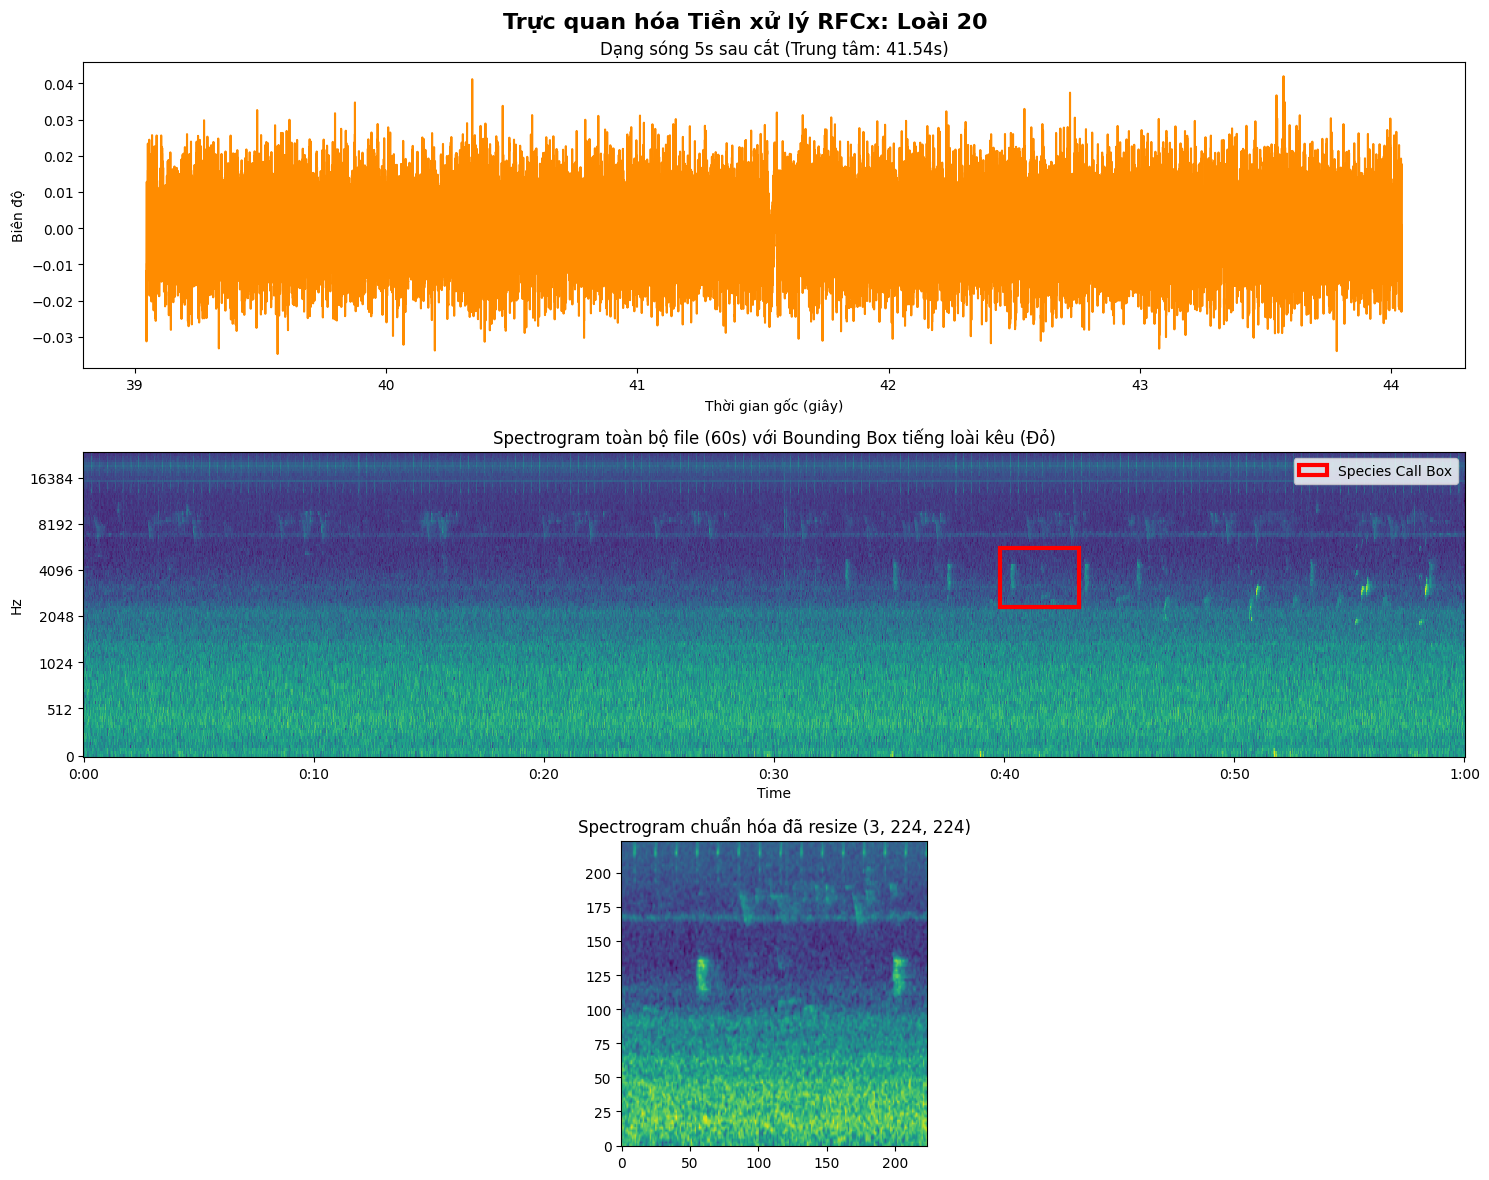

In [6]:
if 'df_tp' in locals() and 'file_to_zip_path' in locals():
    # Chọn 1 dòng ngẫu nhiên để visual
    sample_row = df_tp.sample(1).iloc[0]
    recording_id = sample_row['recording_id']
    species_id = sample_row['species_id']
    t_min, t_max = sample_row['t_min'], sample_row['t_max']
    f_min, f_max = sample_row['f_min'], sample_row['f_max']
    t_center = (t_min + t_max) / 2

    flac_name = f"{recording_id}.flac"
    if flac_name in file_to_zip_path:
        zip_member = file_to_zip_path[flac_name]
        temp_test_file = '/content/temp_test.flac'

        # Giải nén tạm đúng 1 file này
        with zipfile.ZipFile(drive_raw_zip, 'r') as z:
            with z.open(zip_member) as source, open(temp_test_file, 'wb') as target:
                shutil.copyfileobj(source, target)

        print(f"File test: {temp_test_file} | Loài: {species_id} | Khoảng hát: {t_min:.2f}s - {t_max:.2f}s")

        preprocessor = RFCxAudioPreprocessor()
        waveform, spec_db, mel_rgb = preprocessor.preprocess(temp_test_file, t_center)

        # Trực quan hóa
        fig, axs = plt.subplots(3, 1, figsize=(15, 12))

        # 1. Dạng sóng 5 giây
        axs[0].plot(np.linspace(t_center - 2.5, t_center + 2.5, len(waveform[0])), waveform[0].numpy(), color='darkorange')
        axs[0].set_title(f"Dạng sóng 5s sau cắt (Trung tâm: {t_center:.2f}s)")
        axs[0].set_xlabel("Thời gian gốc (giây)")
        axs[0].set_ylabel("Biên độ")

        # 2. Spectrogram gốc và Bounding Box tiếng kêu
        y_full, sr_full = librosa.load(temp_test_file, sr=None)
        S_full = librosa.feature.melspectrogram(y=y_full, sr=sr_full, n_fft=2048, hop_length=512, n_mels=128)
        S_full_db = librosa.power_to_db(S_full, ref=np.max)

        # Xóa file tạm ngay
        if os.path.exists(temp_test_file):
            os.remove(temp_test_file)

        img = librosa.display.specshow(S_full_db, sr=sr_full, hop_length=512, x_axis='time', y_axis='mel', ax=axs[1], cmap='viridis')
        axs[1].set_title(f"Spectrogram toàn bộ file (60s) với Bounding Box tiếng loài kêu (Đỏ)")
        rect = plt.Rectangle((t_min, f_min), t_max - t_min, f_max - f_min,
                             fill=False, edgecolor='red', linewidth=3, label='Species Call Box')
        axs[1].add_patch(rect)
        axs[1].legend()

        # 3. Kênh Mel-Spectrogram đã được resize và chuẩn hóa
        axs[2].imshow(mel_rgb[0].numpy(), cmap='viridis', origin='lower')
        axs[2].set_title("Spectrogram chuẩn hóa đã resize (3, 224, 224)")
        axs[2].grid(False)

        plt.suptitle(f"Trực quan hóa Tiền xử lý RFCx: Loài {species_id}", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("Không tìm thấy file trong zip mapping.")

## 6. Chạy Tiền xử lý Toàn bộ Dữ liệu True Positives (TP) với On-Demand Extraction

In [7]:
if 'df_tp' in locals() and 'file_to_zip_path' in locals():
    processed_tp_records = []
    preprocessor = RFCxAudioPreprocessor()

    print("Bắt đầu tiền xử lý các mẫu True Positives (TP) sử dụng On-Demand Extraction...")

    temp_process_file = '/content/temp_process_tp.flac'

    with zipfile.ZipFile(drive_raw_zip, 'r') as z:
        for idx, row in tqdm(df_tp.iterrows(), total=len(df_tp), desc="Preprocessing RFCx TP"):
            recording_id = row['recording_id']
            species_id = row['species_id']
            t_min, t_max = row['t_min'], row['t_max']
            t_center = (t_min + t_max) / 2

            flac_name = f"{recording_id}.flac"

            if flac_name in file_to_zip_path:
                zip_member = file_to_zip_path[flac_name]

                # 1. Giải nén tạm đúng 1 file này
                with z.open(zip_member) as source, open(temp_process_file, 'wb') as target:
                    shutil.copyfileobj(source, target)

                # 2. Tiền xử lý
                _, _, mel_rgb = preprocessor.preprocess(temp_process_file, t_center)

                # 3. Xóa file tạm ngay
                if os.path.exists(temp_process_file):
                    os.remove(temp_process_file)

                # 4. Lưu tensor PyTorch cục bộ
                out_name = f"{recording_id}_s{species_id}_{t_center:.2f}.pt"
                dest_path = os.path.join(local_processed_dir_tp, out_name)
                torch.save(mel_rgb, dest_path)

                # Ghi nhận log metadata
                processed_tp_records.append({
                    'recording_id': recording_id,
                    'species_id': species_id,
                    'songtype_id': row['songtype_id'],
                    't_min': t_min,
                    't_max': t_max,
                    't_center': t_center,
                    'f_min': row['f_min'],
                    'f_max': row['f_max'],
                    'processed_pt_filename': out_name
                })

    processed_tp_df = pd.DataFrame(processed_tp_records)
    print(f"Đã xử lý {len(processed_tp_df)} mẫu True Positives.")

Bắt đầu tiền xử lý các mẫu True Positives (TP) sử dụng On-Demand Extraction...


Preprocessing RFCx TP: 100%|██████████| 1216/1216 [04:59<00:00,  4.06it/s]

Đã xử lý 1216 mẫu True Positives.


## 7. Chạy Tiền xử lý Dữ liệu False Positives (FP) với On-Demand Extraction

In [8]:
if 'df_fp' in locals() and 'file_to_zip_path' in locals():
    processed_fp_records = []
    preprocessor = RFCxAudioPreprocessor()

    print(f"Bắt đầu tiền xử lý các mẫu False Positives (FP)...")

    temp_process_file = '/content/temp_process_fp.flac'

    # Bạn có thể lựa chọn xử lý subset (ví dụ: head(2000)) hoặc toàn bộ tùy tài nguyên RAM/CPU
    df_fp_subset = df_fp

    with zipfile.ZipFile(drive_raw_zip, 'r') as z:
        for idx, row in tqdm(df_fp_subset.iterrows(), total=len(df_fp_subset), desc="Preprocessing RFCx FP"):
            recording_id = row['recording_id']
            species_id = row['species_id']
            t_min, t_max = row['t_min'], row['t_max']
            t_center = (t_min + t_max) / 2

            flac_name = f"{recording_id}.flac"

            if flac_name in file_to_zip_path:
                zip_member = file_to_zip_path[flac_name]

                # 1. Giải nén tạm đúng 1 file này
                with z.open(zip_member) as source, open(temp_process_file, 'wb') as target:
                    shutil.copyfileobj(source, target)

                # 2. Tiền xử lý
                _, _, mel_rgb = preprocessor.preprocess(temp_process_file, t_center)

                # 3. Xóa file tạm ngay
                if os.path.exists(temp_process_file):
                    os.remove(temp_process_file)

                # 4. Lưu tensor PyTorch cục bộ
                out_name = f"{recording_id}_fp_s{species_id}_{t_center:.2f}.pt"
                dest_path = os.path.join(local_processed_dir_fp, out_name)
                torch.save(mel_rgb, dest_path)

                # Ghi nhận log metadata
                processed_fp_records.append({
                    'recording_id': recording_id,
                    'species_id': species_id,
                    'songtype_id': row['songtype_id'],
                    't_min': t_min,
                    't_max': t_max,
                    't_center': t_center,
                    'f_min': row['f_min'],
                    'f_max': row['f_max'],
                    'processed_pt_filename': out_name
                })

    processed_fp_df = pd.DataFrame(processed_fp_records)
    print(f"Đã xử lý {len(processed_fp_df)} mẫu False Positives.")

Bắt đầu tiền xử lý các mẫu False Positives (FP)...


Preprocessing RFCx FP: 100%|██████████| 7781/7781 [17:17<00:00,  7.50it/s]

Đã xử lý 7781 mẫu False Positives.


## 8. Lưu Metadata mới & Đồng bộ hóa lên Google Drive

In [9]:
# 1. Lưu metadata cho TP và FP lên Google Drive
if 'processed_tp_df' in locals() and len(processed_tp_df) > 0:
    tp_meta_dest = os.path.join(drive_processed_dir, 'rfcx_tp_processed_metadata.csv')
    processed_tp_df.to_csv(tp_meta_dest, index=False)
    print(f"Đã lưu metadata True Positives tại: {tp_meta_dest}")

    # Nén và upload thư mục TP .pt lên Google Drive
    zip_dest_tp = os.path.join(drive_processed_dir, 'rfcx_tp_processed')
    print("Đang nén thư mục True Positives...")
    shutil.make_archive(zip_dest_tp, 'zip', local_processed_dir_tp)
    print(f"Đã lưu file zip True Positives tại: {zip_dest_tp}.zip")

if 'processed_fp_df' in locals() and len(processed_fp_df) > 0:
    fp_meta_dest = os.path.join(drive_processed_dir, 'rfcx_fp_processed_metadata.csv')
    processed_fp_df.to_csv(fp_meta_dest, index=False)
    print(f"Đã lưu metadata False Positives tại: {fp_meta_dest}")

    # Nén và upload thư mục FP .pt lên Google Drive
    zip_dest_fp = os.path.join(drive_processed_dir, 'rfcx_fp_processed')
    print("Đang nén thư mục False Positives...")
    shutil.make_archive(zip_dest_fp, 'zip', local_processed_dir_fp)
    print(f"Đã lưu file zip False Positives tại: {zip_dest_fp}.zip")

Đã lưu metadata True Positives tại: /content/drive/MyDrive/Datasets/BioListenVN/processed/rfcx_tp_processed_metadata.csv
Đang nén thư mục True Positives...
Đã lưu file zip True Positives tại: /content/drive/MyDrive/Datasets/BioListenVN/processed/rfcx_tp_processed.zip
Đã lưu metadata False Positives tại: /content/drive/MyDrive/Datasets/BioListenVN/processed/rfcx_fp_processed_metadata.csv
Đang nén thư mục False Positives...
Đã lưu file zip False Positives tại: /content/drive/MyDrive/Datasets/BioListenVN/processed/rfcx_fp_processed.zip


## 9. Dọn dẹp Thư mục cục bộ

In [10]:
print("Đang dọn dẹp các thư mục tạm cục bộ...")
if os.path.exists(local_processed_dir_tp):
    shutil.rmtree(local_processed_dir_tp)
if os.path.exists(local_processed_dir_fp):
    shutil.rmtree(local_processed_dir_fp)
print("Dọn dẹp thành công!")

Đang dọn dẹp các thư mục tạm cục bộ...
Dọn dẹp thành công!
